In [ ]:
# Load the package 
using ForcedInterfacialWaves
using ForcedInterfacialWaves: ∫

#  ...and plotting dependencies
using Plots, LaTeXStrings

plot_font = "Computer Modern"

default(fontfamily=plot_font, margin=6Plots.mm, linewidth=3, framestyle=:box, label=nothing, color="blue", grid=false,
        fg_legend=false, background_color_legend=false)


# ForcedInterfacialWaves.jl: theory and usage guide

This notebook is a guided Julia usage template for the `ForcedInterfacialWaves.jl` package. It follows the mathematical organization in the documentation and separates the common steady-state formulation from the two transient workflows:

1. the pure-gravity limit, $\alpha=0$, with the analytical $T_0$–$T_4$ decomposition; and
2. the capillary–gravity case, $\alpha>0$, with pole cancellation in a combined integrand.

The code cells are intentionally **commented and unexecuted**. Uncomment a block when you want to run it in a Julia kernel.

## 1. Physical problem and nondimensionalization

A localized pressure forcing acts at the interface between two inviscid, incompressible fluids of infinite depth. After nondimensionalization, use

$$\ell_c=\frac{U^2}{g},\qquad t_c=\frac{U}{g},\qquad p_c=\rho_l U^2.$$

The dimensionless parameters are

$$\alpha=\frac{gT}{\rho_l U^4},\qquad \rho_r=\frac{\rho_u}{\rho_l},\qquad \beta=\frac{1-\rho_r}{1+\rho_r}.$$



The package provides `compute_gravity_parameters()` for $\alpha=0$ and `compute_cg_parameters()` for $\alpha> 0$. Both return parameter objects containing physical scales, nondimensional quantities, roots, forcing amplitude, and quadrature controls.

In [2]:

p_g = compute_gravity_parameters()

UndefVarError: UndefVarError: `compute_gravity_parameters` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [3]:


p_cg = compute_cg_parameters()
(; α, β, ρᵣ, γ_ρ, kₛ, kₗ, F₀, ε,  k_max, atol, rtol ) = p_cg

CapillaryGravityParams(26.7046, 981.0, 72.0, 1.0, 0.001, 75.5996, 0.7269476668297654, 0.027221814475025485, 518.4123050133641, 0.13888559222787725, 0.001, 0.9980019980019981, 0.9990009990009991, 6.010670937188218, 1.1967001366781338, 0.0013888559222787723, 1.0e-6, 1.0e-10, 1.0e-8, Inf, Inf)

## 2. Common structure of the solution

In both physical regimes the interfacial displacement is decomposed as

$$\eta(x,t)=\eta_s(x)+\eta_{\mathrm{tr}}(x,t).$$

The term $\eta_s$ is the nominally time-independent Fourier contribution. The transient contribution also contains a time-independent part in the long-time limit, and this is what selects the physically relevant asymmetric response upstream and downstream of the forcing.

The high-level package interface is `solve(ForcedGravityProblem(...))` or `solve(ForcedGCProblem(...))`. A returned `WaveSolution` contains `η`, `η_steady`, `η_transient`, `x`, and `t`.

## 3. Steady-state formulation

The inverse Fourier representation is

$$\eta(x,t)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty}\exp(ikx)\,\bar{\eta}(k,t)\,dk.$$

For the capillary–gravity problem, the steady part is

$$\frac{\eta_s(x)}{F_0}=-\frac{1}{\pi}\int_0^\infty \frac{\cos(kx)}{\alpha(k-k_l)(k-k_s)}\,dk.$$

Its decomposition into far-field and localized parts is

$$\frac{\eta_s(x)}{F_0}=\frac{\eta_s^{\mathrm{far}}(x)}{F_0}+\frac{\eta_s^{\mathrm{local}}(x)}{F_0},$$

$$\frac{\eta_s^{\mathrm{far}}(x)}{F_0}=\frac{-\sin(k_s|x|)+\sin(k_l|x|)}{\alpha(k_l-k_s)},$$

$$\frac{\eta_s^{\mathrm{local}}(x)}{F_0}=\frac{k_l+k_s}{\pi\alpha}\int_0^\infty \frac{y\exp(-|x|y)}{(y^2+k_l^2)(y^2+k_s^2)}\,dy.$$

The roots and dispersion function are

$$\chi(k)=\sqrt{\beta k+\frac{\alpha}{1+\rho_r}k^3},\qquad k_{l,s}=\frac{1+\rho_r}{2\alpha}\left[1\pm\sqrt{1-\frac{4\alpha\beta}{1+\rho_r}}\right].$$

In [4]:


# Steady solutions do not need a time value. x is a spatial array.
x = make_cg_xgrid(p_cg; Nx=2001, xlim=(-15.0, 15.0))

steady_problem = ForcedGCProblem(p_cg, x)

steady_solution = solve(steady_problem; method=steady(rayleigh_dissipation=false))

steady_solution_rayleigh = solve(steady_problem; method=steady(rayleigh_dissipation=true));


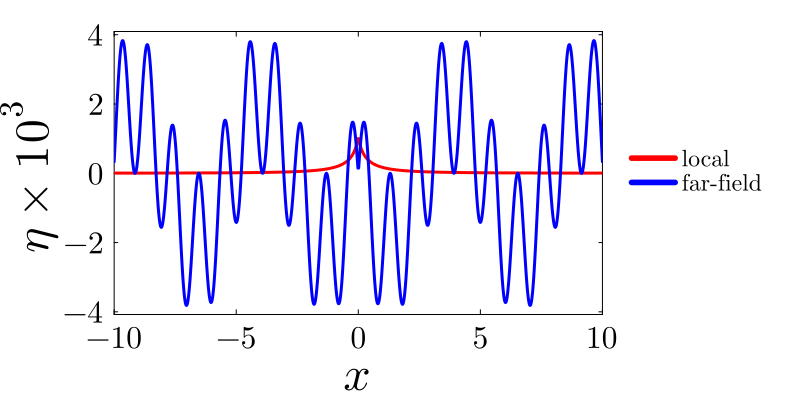

In [5]:
#plot(x, steady_solution.η .* 1e3; label="Rayleigh=false", xlabel=L"x", ylabel=L"η \times 10^{3}", xlims=(-10,10))
plot(x, steady_solution.η_s_local.* 1e3; label="local", color="red", guidefontsize=32, tickfontsize=20, xlabel=L"x", ylabel=L"\eta \times 10^{3}",  legend=:outerright, size=(800,400),legendfontsize=15 , xlims=(-10,10))

plot!(x, steady_solution.η_s_farfield.* 1e3; label="far-field", color="blue")

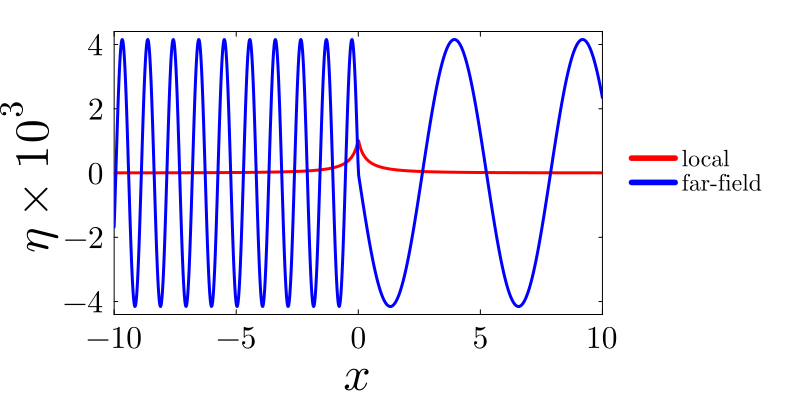

In [6]:
plot(x, steady_solution_rayleigh.η_s_local.* 1e3; label="local", color="red",guidefontsize=32, tickfontsize=20, xlabel=L"x", ylabel=L"\eta \times 10^{3}",  legend=:outerright, size=(800,400),legendfontsize=15, xlims=(-10,10))

plot!(x, steady_solution_rayleigh.η_s_farfield.* 1e3; label="far-field", color="blue")

## 4. Initial-value problem (IVP) for $\alpha=0$ limit (Fig 6 from the paper)
The pure-gravity IVP is written as

$$\eta(x,t)=\eta_s(x)+\eta_{tr}^{(1)}(x,t)+\eta_{tr}^{(2)}(x,t).$$

After contour evaluation and transformations, the transient part is represented by

$$\eta_{tr}(x,t)=\left\{\mathbb{T}_1(x)+\mathbb{T}_2(x,t)+\mathbb{T}_3(x,t)+\mathbb{T}_4(x,t)\right\}F_0,$$

where $a=t-x$, $b=t\sqrt{\beta}/2$, and the sign choice depends on the side of the wavefront:

$$\mathbb{T}_1(x)=\mp\frac{\sin(\beta x)}{1+\rho_r},$$

$$\mathbb{T}_2(x,t)=-\frac{4\beta^{-1}}{\pi(1+\rho_r)}\int_0^\infty \frac{v^2\exp(\mp2av^2\pm2bv)}{\beta+(2v-\sqrt{\beta})^2}\left[\sqrt{\beta}\cos(\sqrt{\beta}tv)\pm(2v-\sqrt{\beta})\sin(\sqrt{\beta}tv)\right]dv,$$

$$\mathbb{T}_3(x,t)=\frac{\beta^{-1/2}}{\pi(1+\rho_r)}\left(1+\frac{t}{2(t-x)}\right)\sqrt{\frac{\pi}{2|a|}}\,\mathcal{F}(a,b),$$

where $\mathcal{F}(a,b)$ is the Fresnel $C/S$ combination documented in the pure-gravity theory page. Finally,

$$\mathbb{T}_4(x,t)=-\frac{1}{\pi(1+\rho_r)}\int_0^\infty \frac{\cos(av^2+2bv)}{v+\sqrt{\beta}}\,dv.$$

The direct CPV verification uses the combined integrand and splits the integration interval around $k=\beta$.

In [7]:

# The solver uses nondimensional time.. pick any t from fig 6 of paper to reproduce corresponding
t = 183.68

sol =  solve(ForcedGravityProblem(p_g, x, t); method=IVP())   # pass p_g , gravity parameters

WaveSolution{Vector{Float64}, Vector{Float64}}([-1.4948776944019625e-5, -1.4903551675930337e-5, -1.4858172888483558e-5, -1.481263448879105e-5, -1.4766930513823045e-5, -1.4721038799965502e-5, -1.4674882093739308e-5, -1.4628458529228512e-5, -1.4581770950637153e-5, -1.4534862423827523e-5  …  -0.002110892815801903, -0.002083789409552013, -0.0020562170165886965, -0.0020281797219677206, -0.0019996842419610843, -0.001970738488521308, -0.0019413461233451085, -0.0019115161432044685, -0.0018812545021141395, -0.0018505687666872874], [-0.000931511669188651, -0.0009467699781741538, -0.0009618156757467456, -0.000976645389314265, -0.0009912557946833785, -0.0010056436168045164, -0.001019805630505789, -0.0010337386612157312, -0.0010474395856747058, -0.0010609053326348062  …  -0.0010609053326348062, -0.0010474395856747058, -0.0010337386612157312, -0.001019805630505789, -0.0010056436168045164, -0.0009912557946833785, -0.000976645389314265, -0.0009618156757467456, -0.0009467699781741538, -0.00093151166918

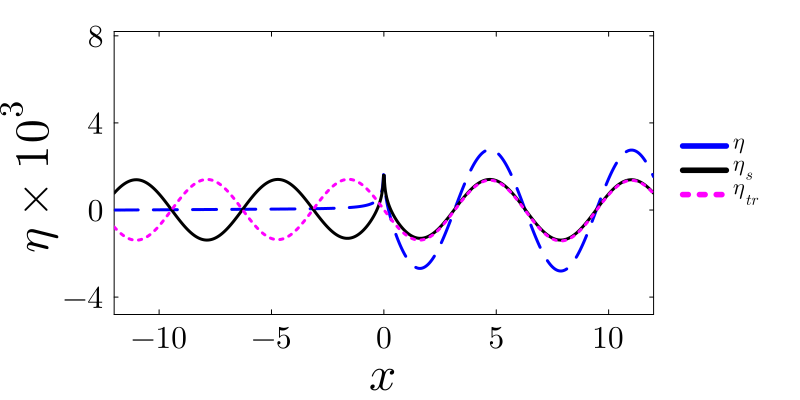

In [8]:
plot(x, sol.η .* 1e3,  label=L"\eta", color="blue",linestyle=:dash,guidefontsize=32, tickfontsize=20, xlabel=L"x", ylabel=L"\eta \times 10^{3}",  legend=:outerright, size=(800,400),legendfontsize=15, ylims=(-4.8, 8.2) , yticks=[-4, 0,4,8])

plot!(x, sol.η_steady .* 1e3,  label=L"\eta_s", color="black",guidefontsize=32, tickfontsize=20, xlabel=L"x", ylabel=L"\eta \times 10^{3}", xlim=(-12,12))

plot!(x, sol.η_transient .* 1e3,  label=L"\eta_{tr}", color="magenta",linestyle=:dot,guidefontsize=32, tickfontsize=20, xlabel=L"x", ylabel=L"\eta \times 10^{3}")

## 4. Initial-value problem (IVP) for $\alpha > 0$ limit (Fig 7 and 8 from the paper)

For $\alpha>0$, the transient contribution is

$$\frac{\eta_{\mathrm{tr}}(x,t)}{F_0}=-\frac{1}{2\pi}\left[\mathbb{I}_3(x,t)+\mathbb{I}_4(x,t)\right],$$

with

$$\mathbb{I}_{3,4}(x,t)=-\frac{1+\rho_r}{\alpha}\int_0^\infty \frac{(k\pm\chi(k))\cos\left[t(k\mp\chi(k))-kx\right]}{(1+\alpha k^2-\rho_r)(k-k_l)(k-k_s)}\,dk.$$



#### Plot for $\frac{-\mathbb{I}_{4}(x,t)}{2\pi}$ , Fig 7 from manuscript.
In manuscript the profiles are shifted by two units for each non-dimensional $t$

In [42]:
t = 0.34
I4 = compute_cg_I4_profile(x, t, p_cg; method=:threaded_vector)

2000-element Vector{Float64}:
 -0.007295797364618599
 -0.007305411692497367
 -0.007315047896306426
 -0.007324706585097247
 -0.007334385528551649
 -0.007344087677695948
 -0.007353812111788827
 -0.007363558559474584
 -0.007373327159200608
 -0.007383116038941663
  ⋮
 -0.007360538494122744
 -0.007350811531134815
 -0.007341016085144962
 -0.0073311589558908916
 -0.00732129433721425
 -0.007311573773122667
 -0.007302195556012029
 -0.0072931087243100455
 -0.007283748278791223

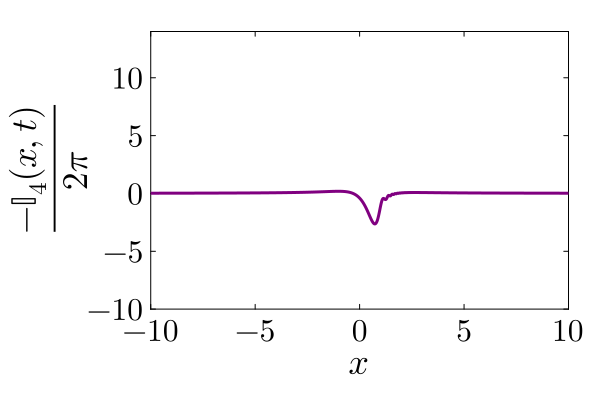

In [43]:
plot(x, -(1/2*pi)*I4, color="purple", xlim=(-10,10), ylim=(-10,14),guidefontsize=24, tickfontsize=20, xlabel=L"x", ylabel=L"\frac{-\mathbb{I}_{4}(x,t)}{2\pi}")

In [37]:
# The solver uses nondimensional time.. pick any t from fig 6 of paper to reproduce corresponding
t = 367.35

sol_sym_8 =  solve(ForcedGCProblem(p_cg, x, t); method=IVP())   # pass p_g , gravity parameters

WaveSolution{Vector{Float64}, Vector{Float64}}([0.0035046047083174617, 0.003720560561503627, 0.003907066248373873, 0.004062657962203271, 0.004186119749603497, 0.004276496737039321, 0.004333097004568872, 0.004355502611819373, 0.0043435711111103285, 0.004297434469419656  …  0.0035951252709082357, 0.003569149410226971, 0.0035420720204104284, 0.003513877710668574, 0.0034845526926993377, 0.0034540821096217303, 0.0034224518368752488, 0.0033896495438377997, 0.003355661368832502, 0.0033204762244294947], [0.003312907395293826, 0.0034383944905028306, 0.003548829508117369, 0.003643490226112837, 0.0037217783426007228, 0.0037832243410145933, 0.0038274911253891914, 0.003854376887116143, 0.0038638165143343923, 0.003855882239647915  …  0.0038558822396481452, 0.0038638165143344947, 0.003854376887116426, 0.003827491125388821, 0.0037832243410142277, 0.003721778342599974, 0.003643490226111884, 0.003548829508116637, 0.003438394490502049, 0.0033129073952934815], [1.9347007165705817e-6, 1.9385091091375997e-6

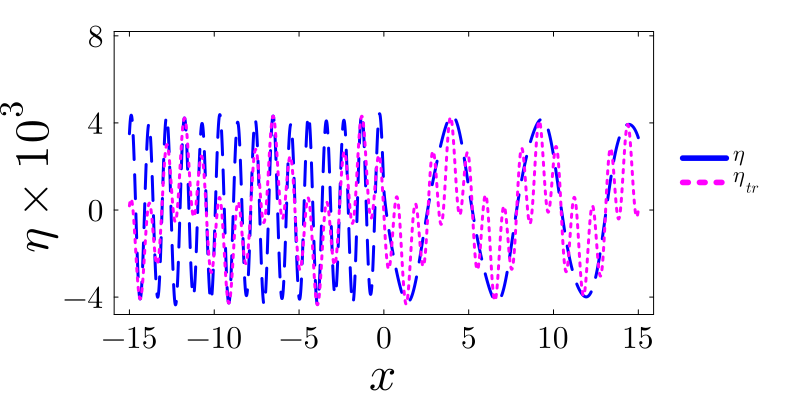

In [39]:
plot(x, sol_sym_8.η .* 1e3,  label=L"\eta", color="blue",linestyle=:dash,guidefontsize=32, tickfontsize=20, xlabel=L"x", ylabel=L"\eta \times 10^{3}",  legend=:outerright, size=(800,400),legendfontsize=15, ylims=(-4.8, 8.2) , yticks=[-4, 0,4,8])

# for plotting η_steady, uncomment the ine below...

#plot!(x, sol_sym_8.η_steady .* 1e3,  label=L"\eta_s", color="black",guidefontsize=32, tickfontsize=20, xlabel=L"x", ylabel=L"\eta \times 10^{3}", xlim=(-10,10))

plot!(x, sol_sym_8.η_transient .* 1e3,  label=L"\eta_{tr}", color="magenta",linestyle=:dot,guidefontsize=32, tickfontsize=20, xlabel=L"x", ylabel=L"\eta \times 10^{3}")

## 5. Comparison with nonlinear simulations (Fig 10)

In [40]:
t_dim = 25   # [use t_dim only from array [1, 3, 7, 15, 25, 60, 145, 300]; for reproducing fig 10 from manuscript

t = t_dim/(100*p_cg.t_c)  # 100 here is factor due to saving sim. data in fixed intervals of dt = 0.01 seconds

# loading simulation data
using DelimitedFiles
data_sim = sortslices(readdlm("if_$(Int(t_dim)).csv", ',', Float64, skipstart=1),dims=1,  by=x->x[6])
x_sim = @views data_sim[:,6]/p_cg.l_c
y_sim = @views data_sim[:,7]/p_cg.l_c


sol_sym =  solve(ForcedGCProblem(p_cg, x, t); method=IVP());

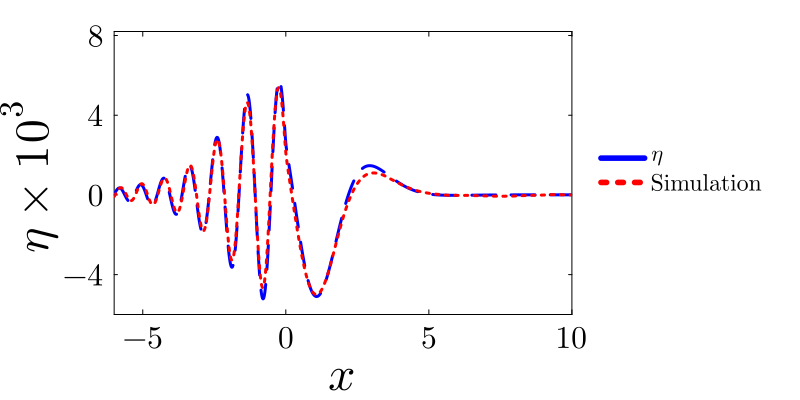

In [41]:
plot(x, sol_sym.η .* 1e3,  label=L"\eta", color="blue",linestyle=:dash,guidefontsize=32, tickfontsize=20, xlabel=L"x", ylabel=L"\eta \times 10^{3}",  legend=:outerright, size=(800,400),legendfontsize=15, xlims=(-6,10), ylims=(-6, 8.2) , yticks=[-4, 0,4,8])

plot!(x_sim, y_sim .* 1e3, color="red", linestyle=:dot, label="Simulation")